<a href="https://colab.research.google.com/github/doyoun1355/NVIDIA/blob/Yolo_V8/Yolo_v8_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# YOLOv8 라이브러리 설치
!pip install ultralytics --quiet

# 필요한 라이브러리 불러오기
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.3/977.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultr

Saving 1.jpg to 1.jpg
업로드된 이미지 경로: 1.jpg


100%|██████████| 6.25M/6.25M [00:00<00:00, 111MB/s]



image 1/1 /content/1.jpg: 384x640 6 persons, 47.6ms
Speed: 14.8ms preprocess, 47.6ms inference, 331.0ms postprocess per image at shape (1, 3, 384, 640)


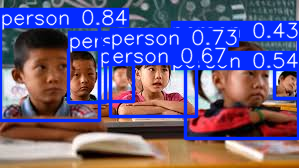

감지된 사람 수: 6
사람 1: 위치 (0.4, 26.2) ~ (99.4, 120.4), 신뢰도 83.50%
사람 2: 위치 (110.7, 46.2) ~ (196.9, 116.2), 신뢰도 72.68%
사람 3: 위치 (99.8, 64.4) ~ (134.0, 101.1), 신뢰도 67.49%
사람 4: 위치 (274.9, 69.2) ~ (298.9, 98.6), 신뢰도 53.60%
사람 5: 위치 (185.7, 39.3) ~ (298.8, 138.4), 신뢰도 43.40%
사람 6: 위치 (68.2, 49.5) ~ (105.5, 102.2), 신뢰도 39.54%


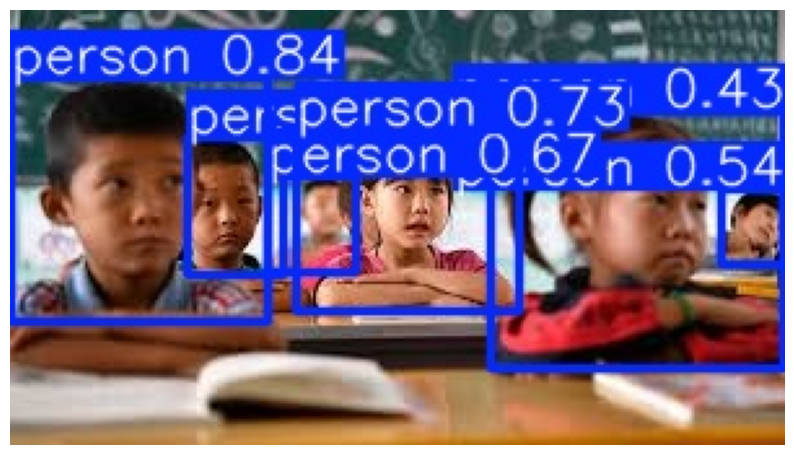

In [5]:
from google.colab import files
# 사용자 이미지 업로드
uploaded = files.upload()

# 업로드된 파일 이름 가져오기
image_path = list(uploaded.keys())[0]
print(f"업로드된 이미지 경로: {image_path}")

# YOLOv8 모델 불러오기 (yolov8n: 가벼운 버전, yolov8s/m/l/x 가능)
model = YOLO("yolov8n.pt")

# 객체 감지 수행
results = model(image_path)

# 결과 시각화
results[0].show()  # 감지된 결과 표시

# 결과 데이터 가져오기
detections = results[0].boxes.data  # 검출된 객체 리스트
class_names = results[0].names       # 클래스 이름 리스트

# 사람(person)만 필터링 (클래스 ID 0이 'person'임)
person_detections = [d for d in detections if int(d[5]) == 0]

print(f"감지된 사람 수: {len(person_detections)}")
for i, det in enumerate(person_detections):
    x1, y1, x2, y2, conf, cls = det.tolist()
    print(f"사람 {i+1}: 위치 ({x1:.1f}, {y1:.1f}) ~ ({x2:.1f}, {y2:.1f}), 신뢰도 {conf:.2%}")

# 감지된 이미지 저장
results[0].save(filename="detected_image.jpg")

# 저장된 이미지 출력
img = cv2.imread("detected_image.jpg")
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
